In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import hopsworks
from dotenv import load_dotenv
load_dotenv('../.env')

project = hopsworks.login()
fs = project.get_feature_store()
fg = fs.get_feature_group('aqi_features', version=1)
df = fg.read()
df = df.sort_values('timestamp').reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head()

D:\anaconda\envs\pearls_aqi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-05-12 01:33:16,923 INFO: Initializing external client
2026-05-12 01:33:16,925 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443




To ensure compatibility please install the latest bug fix release matching the minor version of your backend (4.7) by running 'pip install hopsworks==4.7.*'


2026-05-12 01:33:20,932 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32001
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (8.83s) 
Shape: (9048, 31)
Date range: 2025-04-25 00:00:00+00:00 → 2026-05-10 23:00:00+00:00


,timestamp,pm2_5,pm10,no2,o3,so2,co,temperature,humidity,wind_speed,...,pm2_5_lag_24h,aqi_lag_48h,pm2_5_lag_48h,aqi_lag_72h,pm2_5_lag_72h,aqi_change_rate,target_aqi_24h,target_aqi_48h,target_aqi_72h,has_target
0,2025-04-25 00:00:00+00:00,17.799999,44.700001,9.7,62.0,7.6,312.0,25.600000,95.064674,8.482947,...,NaN,NaN,NaN,NaN,NaN,NaN,61.43,81.56,71.12,1
1,2025-04-25 01:00:00+00:00,18.299999,45.099998,12.4,61.0,8.3,373.0,25.500000,97.358009,6.660000,...,NaN,NaN,NaN,NaN,NaN,0.93,64.23,81.74,70.56,1
2,2025-04-25 02:00:00+00:00,21.000000,47.400002,16.0,61.0,9.4,458.0,26.049999,95.933182,8.089993,...,NaN,NaN,NaN,NaN,NaN,5.03,70.56,84.35,72.80,1
3,2025-04-25 03:00:00+00:00,22.900000,56.200001,17.6,68.0,10.9,500.0,27.500000,87.305000,7.907718,...,NaN,NaN,NaN,NaN,NaN,3.54,77.83,87.14,76.71,1
4,2025-04-25 04:00:00+00:00,24.900000,65.900002,15.1,87.0,13.5,459.0,29.400000,73.643013,7.132181,...,NaN,NaN,NaN,NaN,NaN,3.73,80.81,87.14,77.64,1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
print("=== Nulls per column ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== Duplicates ===")
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")

print("\n=== Timestamp continuity ===")
expected_hours = int((df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 3600) + 1
actual_hours = len(df)
print(f"Expected hours: {expected_hours}")
print(f"Actual rows: {actual_hours}")
print(f"Missing hours: {expected_hours - actual_hours}")

df_sorted = df.sort_values('timestamp').reset_index(drop=True)
gaps = df_sorted['timestamp'].diff()
big_gaps = gaps[gaps > pd.Timedelta(hours=1)]
print(f"\nGaps > 1 hour: {len(big_gaps)}")
if len(big_gaps) > 0:
    print("Top 5 largest gaps:")
    print(big_gaps.nlargest(5))

=== Nulls per column ===
rolling_30day_std      2
aqi_lag_24h           48
pm2_5_lag_24h         48
aqi_lag_48h          106
pm2_5_lag_48h        106
aqi_lag_72h          298
pm2_5_lag_72h        298
aqi_change_rate        2
target_aqi_24h       288
target_aqi_48h       312
target_aqi_72h       336
dtype: int64

=== Duplicates ===
Duplicate timestamps: 0

=== Timestamp continuity ===
Expected hours: 9144
Actual rows: 9048
Missing hours: 96

Gaps > 1 hour: 1
Top 5 largest gaps:
8784   4 days 01:00:00
Name: timestamp, dtype: timedelta64[us]


In [4]:
gap_idx = big_gaps.idxmax()
print(f"Gap of {big_gaps[gap_idx]}")
print(f"Last row before gap: {df_sorted.loc[gap_idx-1, 'timestamp']}")
print(f"First row after gap: {df_sorted.loc[gap_idx, 'timestamp']}")

Gap of 4 days 01:00:00
Last row before gap: 2026-04-25 23:00:00+00:00
First row after gap: 2026-04-30 00:00:00+00:00


**Data quality summary:**

- 9,048 hourly rows from Apr 25, 2025 → May 10, 2026 (~12.5 months)
- No duplicate timestamps
- 1.05% missing hours, almost entirely from a single 4-day gap (Apr 25–30, 2025) at the boundary between initial backfill and the start of automated hourly ingestion
- Nulls in lag columns (start of series) and target columns (end of series) are expected boundary effects, not data issues

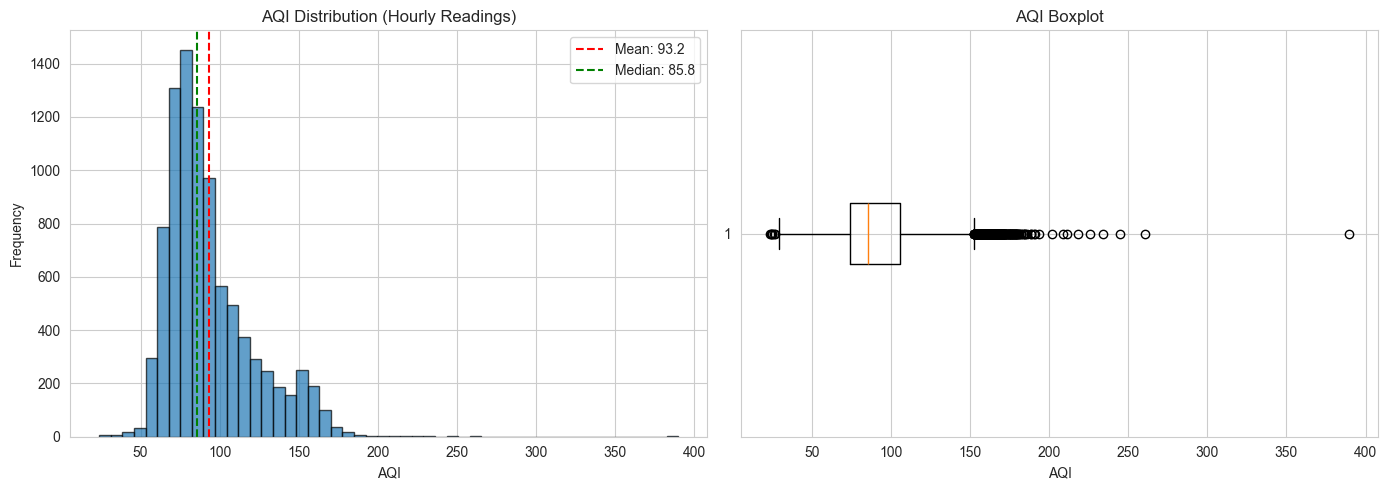


=== AQI Summary Stats ===
count    9048.000000
mean       93.234131
std        27.334324
min        23.890000
25%        74.290000
50%        85.840000
75%       105.680000
max       389.720000
Name: aqi, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['aqi'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].set_title('AQI Distribution (Hourly Readings)')
axes[0].axvline(df['aqi'].mean(), color='red', linestyle='--', label=f"Mean: {df['aqi'].mean():.1f}")
axes[0].axvline(df['aqi'].median(), color='green', linestyle='--', label=f"Median: {df['aqi'].median():.1f}")
axes[0].legend()

axes[1].boxplot(df['aqi'].dropna(), vert=False)
axes[1].set_xlabel('AQI')
axes[1].set_title('AQI Boxplot')

plt.tight_layout()
plt.show()

print("\n=== AQI Summary Stats ===")
print(df['aqi'].describe())

**AQI distribution observations:**

- Right-skewed with mean 93.2, median 85.8, std 27.3
- Median falls in the "Moderate" AQI category (51–100)
- 75th percentile at 106 — most hours stay below "Unhealthy for Sensitive Groups"
- Long upper tail with extreme outliers (max 389.7) suggesting episodic pollution events (dust storms, smog episodes)
- Minimum 23.9 — Karachi rarely hits "Good" AQI (<50)

=== AQI Category Distribution ===
1. Good (0-50): 46 hours (0.51%)
2. Moderate (51-100): 6400 hours (70.73%)
3. Unhealthy for Sensitive (101-150): 2031 hours (22.45%)
4. Unhealthy (151-200): 562 hours (6.21%)
5. Very Unhealthy (201-300): 8 hours (0.09%)
6. Hazardous (301+): 1 hours (0.01%)


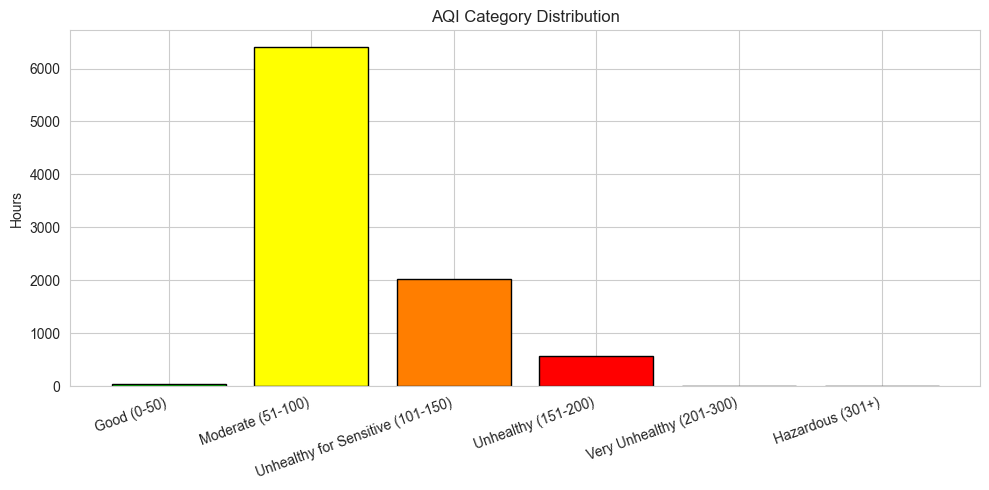

In [7]:
def aqi_category(aqi):
    if aqi <= 50: return '1. Good (0-50)'
    elif aqi <= 100: return '2. Moderate (51-100)'
    elif aqi <= 150: return '3. Unhealthy for Sensitive (101-150)'
    elif aqi <= 200: return '4. Unhealthy (151-200)'
    elif aqi <= 300: return '5. Very Unhealthy (201-300)'
    else: return '6. Hazardous (301+)'

df['aqi_category'] = df['aqi'].apply(aqi_category)
cat_counts = df['aqi_category'].value_counts().sort_index()
cat_pct = (cat_counts / len(df) * 100).round(2)

print("=== AQI Category Distribution ===")
for cat, count in cat_counts.items():
    print(f"{cat}: {count} hours ({cat_pct[cat]}%)")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
ax.bar(range(len(cat_counts)), cat_counts.values, color=colors[:len(cat_counts)], edgecolor='black')
ax.set_xticks(range(len(cat_counts)))
ax.set_xticklabels([c.split('. ')[1] for c in cat_counts.index], rotation=20, ha='right')
ax.set_ylabel('Hours')
ax.set_title('AQI Category Distribution')
plt.tight_layout()
plt.show()

**AQI category insights:**

- 70.7% of hours fall in "Moderate" — this is Karachi's baseline air quality
- 22.5% reach "Unhealthy for Sensitive Groups" — common but not majority
- Only 0.51% are "Good" — clean air is rare
- "Hazardous" (the alert threshold) occurred in just 1 hour out of 9,048 (~0.01%) — extremely rare, justifying alert-based UX rather than constant warnings
- Class imbalance is significant — model evaluation should consider performance across categories, not just overall RMSE

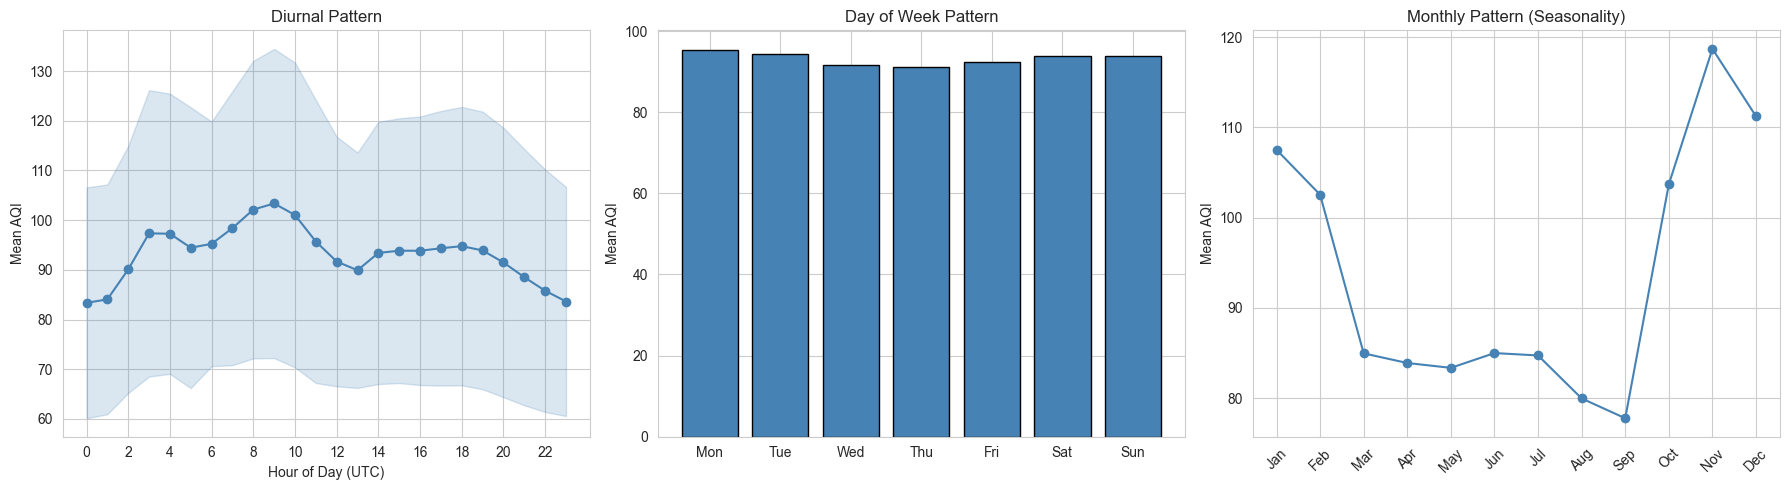

In [15]:
# section 4: time patterns
df['hour'] = df['timestamp'].dt.hour
df['day_of_week_name'] = df['timestamp'].dt.day_name()
df['month_name'] = df['timestamp'].dt.month_name()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hourly = df.groupby('hour')['aqi'].agg(['mean', 'std'])
axes[0].plot(hourly.index, hourly['mean'], marker='o', color='steelblue')
axes[0].fill_between(hourly.index, hourly['mean']-hourly['std'], hourly['mean']+hourly['std'], alpha=0.2, color='steelblue')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Mean AQI')
axes[0].set_title('Diurnal Pattern')
axes[0].set_xticks(range(0, 24, 2))

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week_name')['aqi'].mean().reindex(dow_order)
axes[1].bar(range(7), dow.values, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in dow_order])
axes[1].set_ylabel('Mean AQI')
axes[1].set_title('Day of Week Pattern')

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly = df.groupby('month_name')['aqi'].mean().reindex(month_order).dropna()
axes[2].plot(range(len(monthly)), monthly.values, marker='o', color='steelblue')
axes[2].set_xticks(range(len(monthly)))
axes[2].set_xticklabels([m[:3] for m in monthly.index], rotation=45)
axes[2].set_ylabel('Mean AQI')
axes[2].set_title('Monthly Pattern (Seasonality)')

plt.tight_layout()
plt.show()

**Time pattern insights:**

- **Diurnal:** AQI peaks ~9:00 UTC (2 PM PKT) and dips overnight — supports including `hour` as a feature
- **Day of week:** essentially flat — Karachi air quality has no weekly cycle, suggesting industrial/baseline emissions rather than commuter-driven. `is_weekend` and `day_of_week` features likely have weak predictive power
- **Monthly:** strong winter peak (Nov ~118) and summer trough (Sep ~78). Winter cold-air inversion traps pollution; monsoon months wash it out. This seasonality justifies `month` and `rolling_30day_avg` as features

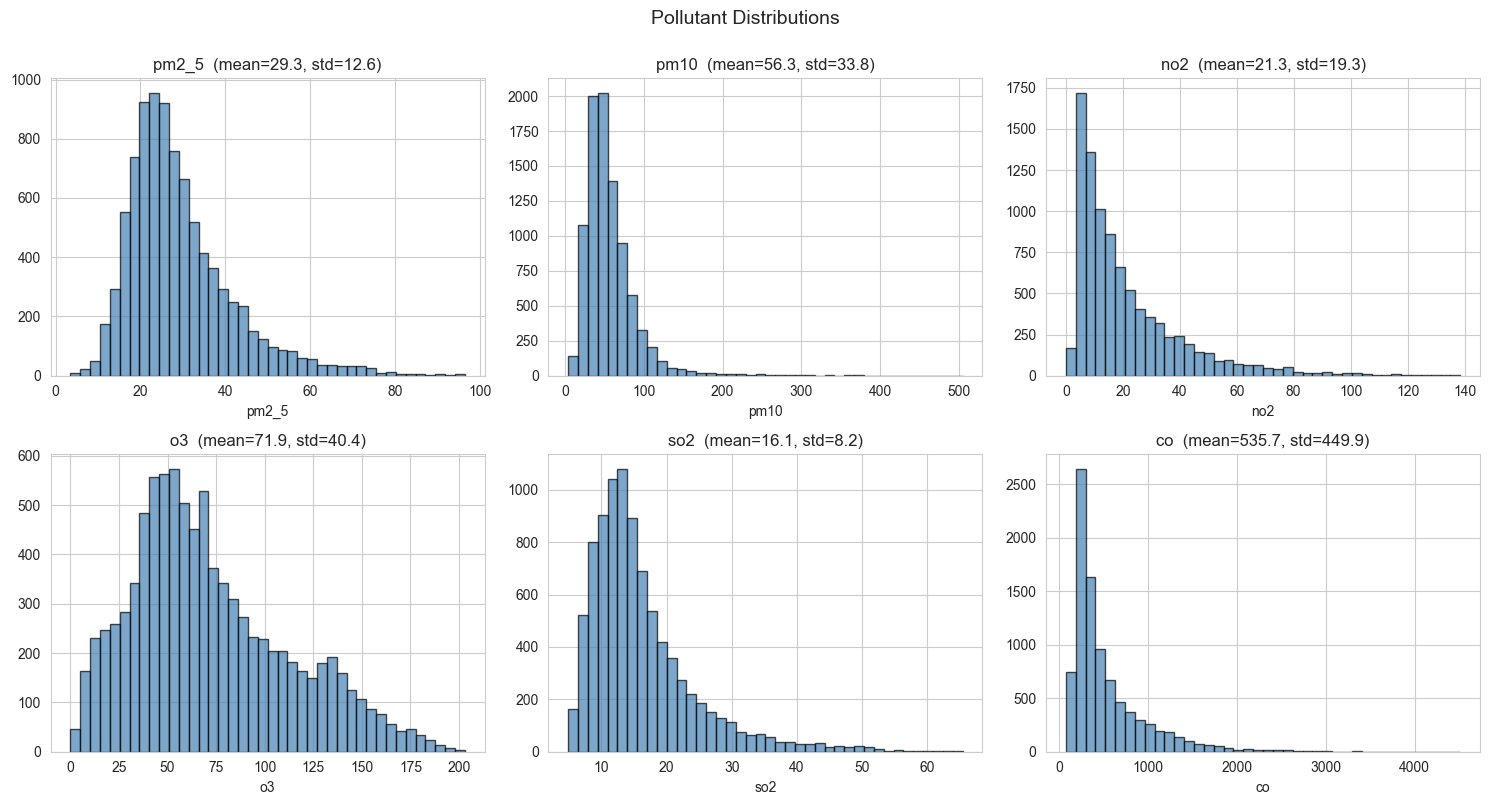

In [14]:
# section 5: feature fistributions-pollutants
pollutants = ['pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), pollutants):
    ax.hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}  (mean={df[col].mean():.1f}, std={df[col].std():.1f})')
    ax.set_xlabel(col)

plt.suptitle('Pollutant Distributions', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**Pollutant distribution insights:**

- PM2.5, PM10, NO2, SO2, CO all right-skewed with long tails — typical pollution distributions where most hours are moderate but episodic spikes occur
- O3 shows a bimodal distribution (peaks ~50 and ~125), reflecting day/night photochemistry — O3 forms in sunlight via NOx + VOC reactions
- CO has the most extreme range (mean 536, max ~4000) — likely traffic/combustion spike events
- Skewness suggests log-transformations could help linear models, though tree-based and Ridge with engineered features handle this adequately

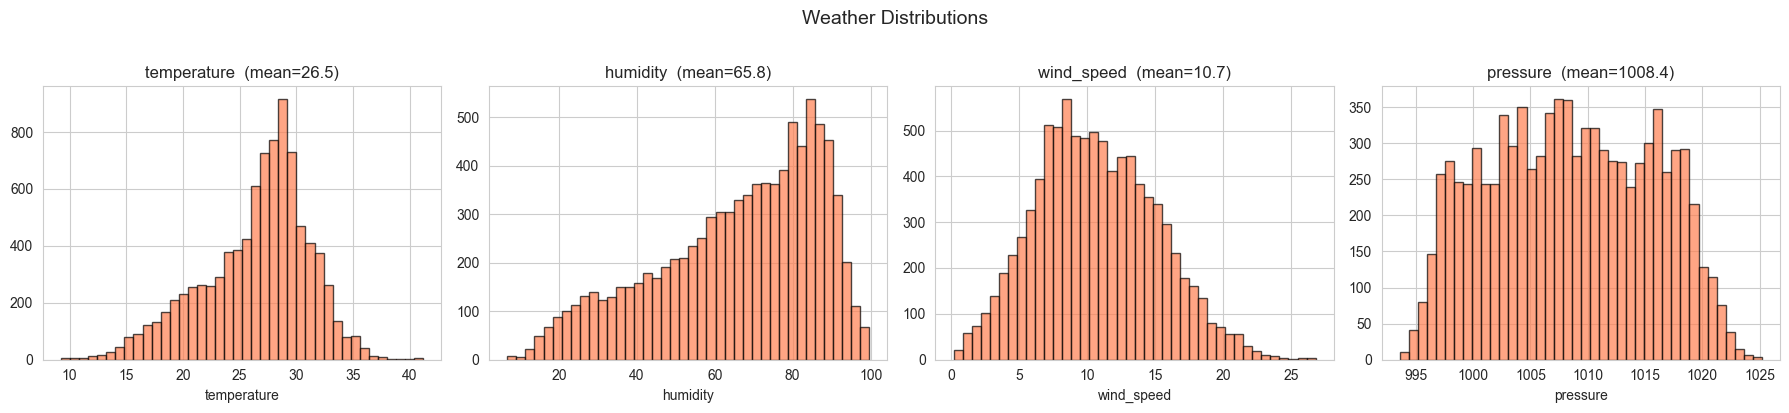

In [13]:
# weather distributions
weather = ['temperature', 'humidity', 'wind_speed', 'pressure']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, weather):
    ax.hist(df[col].dropna(), bins=40, color='coral', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}  (mean={df[col].mean():.1f})')
    ax.set_xlabel(col)

plt.suptitle('Weather Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Weather distribution insights:**

- Temperature ranges 10-40°C reflecting Karachi's seasonal swing, mean 26.5°C
- Humidity is left-skewed and concentrated in 70-90% range — coastal city dominated by humid days
- Wind speed is near-normal around 10.7 m/s, reflecting consistent Arabian Sea breeze patterns
- Pressure is nearly uniform in a tight 995-1025 hPa band — typical for sea-level coastal locations and unlikely to be a strong predictor

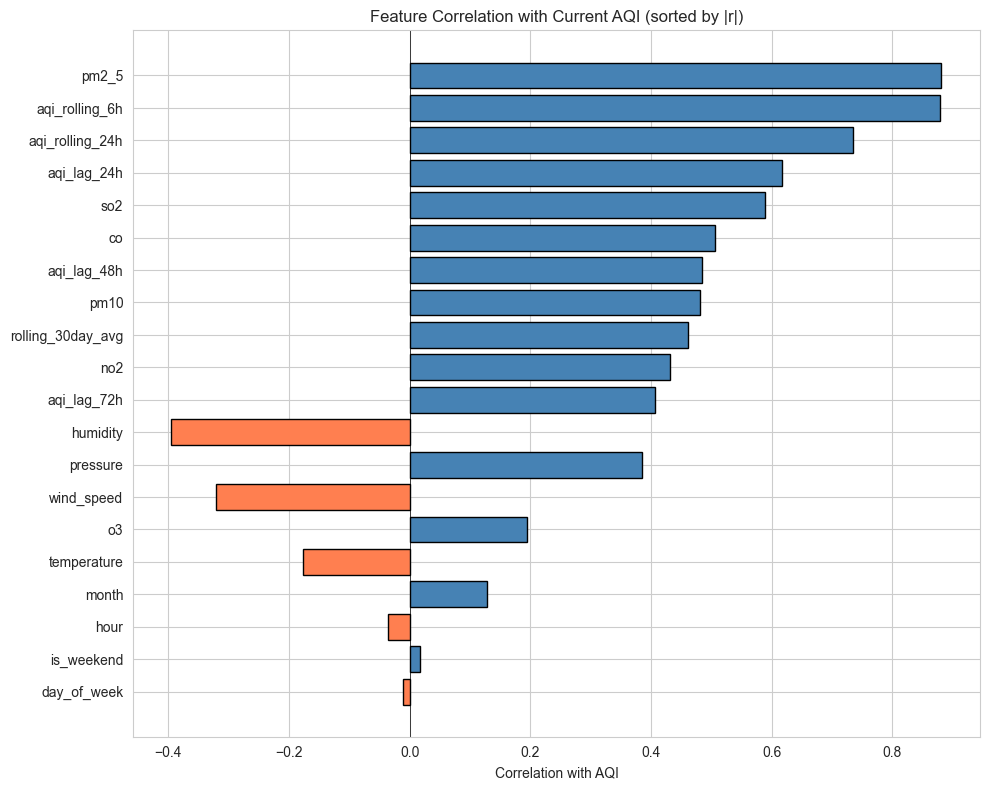


=== Top 10 features by absolute correlation ===
pm2_5                0.881
aqi_rolling_6h       0.879
aqi_rolling_24h      0.734
aqi_lag_24h          0.616
so2                  0.589
co                   0.506
aqi_lag_48h          0.484
pm10                 0.480
rolling_30day_avg    0.462
no2                  0.431
Name: aqi, dtype: float64


In [12]:
# Section 6: correlations with AQI
feature_cols = ['pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co',
                'temperature', 'humidity', 'wind_speed', 'pressure',
                'hour', 'day_of_week', 'month', 'is_weekend',
                'aqi_rolling_6h', 'aqi_rolling_24h', 'rolling_30day_avg',
                'aqi_lag_24h', 'aqi_lag_48h', 'aqi_lag_72h']

corrs = df[feature_cols + ['aqi']].corr()['aqi'].drop('aqi').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'coral' for c in corrs.values]
ax.barh(range(len(corrs)), corrs.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index)
ax.set_xlabel('Correlation with AQI')
ax.set_title('Feature Correlation with Current AQI (sorted by |r|)')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n=== Top 10 features by absolute correlation ===")
print(corrs.head(10).round(3))

**Correlation insights:**

- **PM2.5 (r=0.88)** is the dominant driver — consistent with the US AQI formula being PM2.5-heavy
- **Rolling and lag features show strong correlations** (rolling_6h: 0.88, rolling_24h: 0.73, lag_24h: 0.62) — confirming AQI has strong temporal autocorrelation and recent history is highly predictive
- **Humidity (-0.40) and wind speed (-0.32)** are the most useful weather signals — both inversely related to AQI (wet/windy weather disperses pollutants)
- **Day-of-week and is_weekend (~0)** confirm no weekly cycle in Karachi air quality, supporting the diurnal/seasonality findings above
- These correlations justify the feature engineering decisions: PM2.5 + lag/rolling AQI + humidity/wind form the predictive core

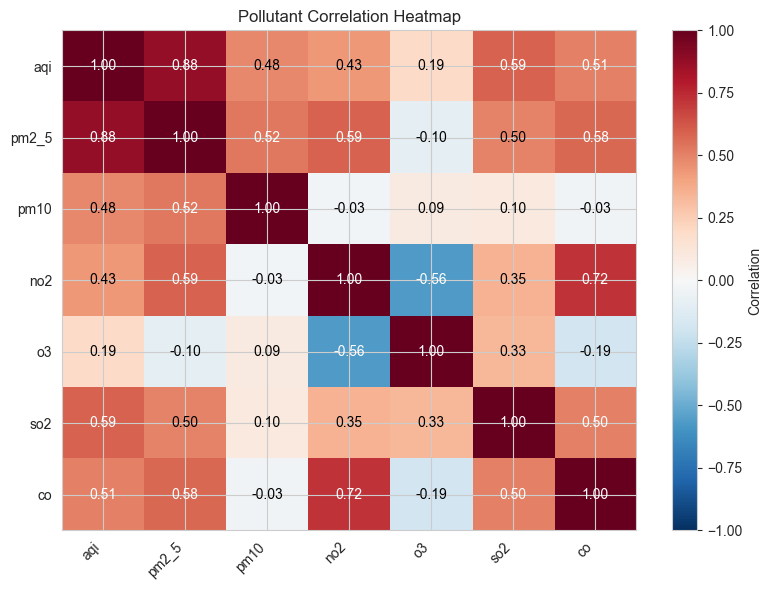

In [16]:
# Pollutant correlation heatmap (with AQI)
import numpy as np

cols = ['aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'so2', 'co']
corr_matrix = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

# Annotate
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix.values[i,j]) > 0.5 else 'black', fontsize=10)

plt.colorbar(im, ax=ax, label='Correlation')
ax.set_title('Pollutant Correlation Heatmap')
plt.tight_layout()
plt.show()

**Pollutant inter-correlation insights:**

- **NO2 and CO (r=0.72)** move together — both are traffic/combustion byproducts
- **NO2 and O3 (r=-0.56)** show classic photochemical anticorrelation — NO scavenges O3 at night while sunlight converts NO2 to O3 during the day
- **PM10 is largely independent** of combustion pollutants (NO2, CO ≈ 0) — suggests Karachi PM10 is dominated by dust/aerosol sources rather than combustion
- **O3 has the weakest correlation with AQI (0.19)** — confirming Karachi's AQI is rarely ozone-driven; particulate matter dominates the index

=== Correlation of current AQI with future targets ===
Current: r = 1.000
24h ahead: r = 0.628
48h ahead: r = 0.489
72h ahead: r = 0.410


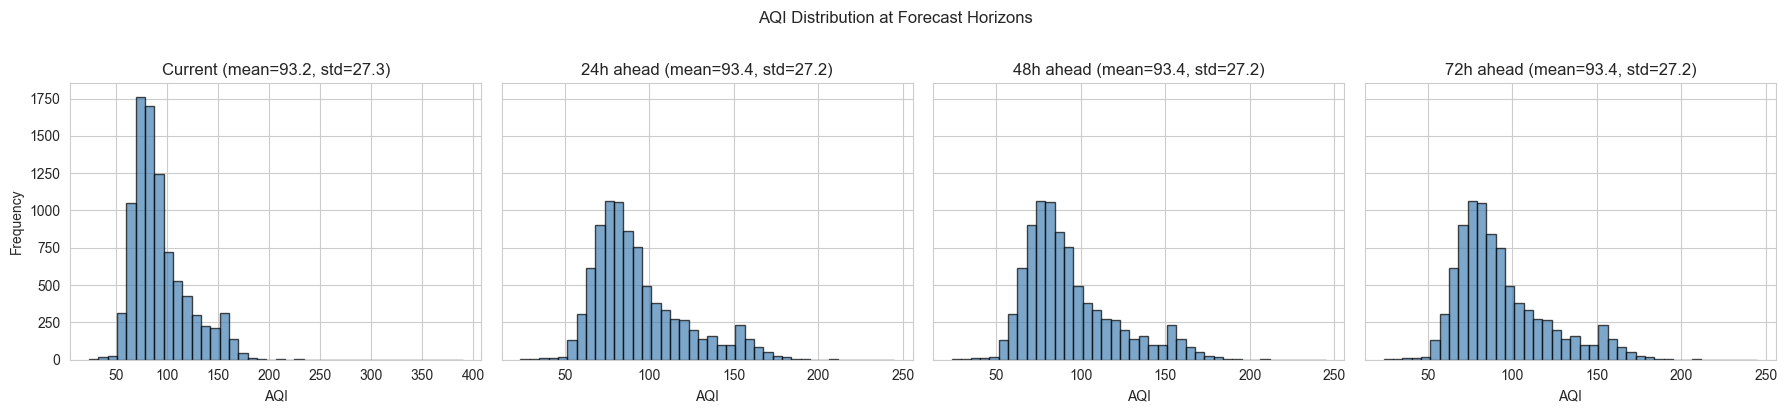

In [17]:
# Section 7: Target Horizon Analysis - how correlation degrades with forecast distance
horizons = ['aqi', 'target_aqi_24h', 'target_aqi_48h', 'target_aqi_72h']
horizon_labels = ['Current', '24h ahead', '48h ahead', '72h ahead']

# Self-correlation of AQI with future values
target_corrs = df[['aqi'] + ['target_aqi_24h', 'target_aqi_48h', 'target_aqi_72h']].corr()['aqi']

print("=== Correlation of current AQI with future targets ===")
for h, label in zip(horizons, horizon_labels):
    print(f"{label}: r = {target_corrs[h]:.3f}")

# Distribution comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, h, label in zip(axes, horizons, horizon_labels):
    ax.hist(df[h].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{label} (mean={df[h].mean():.1f}, std={df[h].std():.1f})')
    ax.set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
plt.suptitle('AQI Distribution at Forecast Horizons', y=1.02)
plt.tight_layout()
plt.show()

**Forecast horizon insights:**

- Correlation between current and future AQI decays predictably with horizon:
  - 24h ahead: r = 0.63 (strong)
  - 48h ahead: r = 0.49 (moderate)
  - 72h ahead: r = 0.41 (weaker but still useful)
- Target distributions are nearly identical across horizons (mean ~93.4, std ~27.2) — confirming no systematic drift, only decay in temporal autocorrelation
- This decay is a fundamental property of the data, explaining why model R² scores naturally degrade at longer horizons (0.35 / 0.18 / 0.13 at 24/48/72h)
- The decay justifies using widening confidence intervals at longer horizons (40 → 42 → 51 from the CQR system)

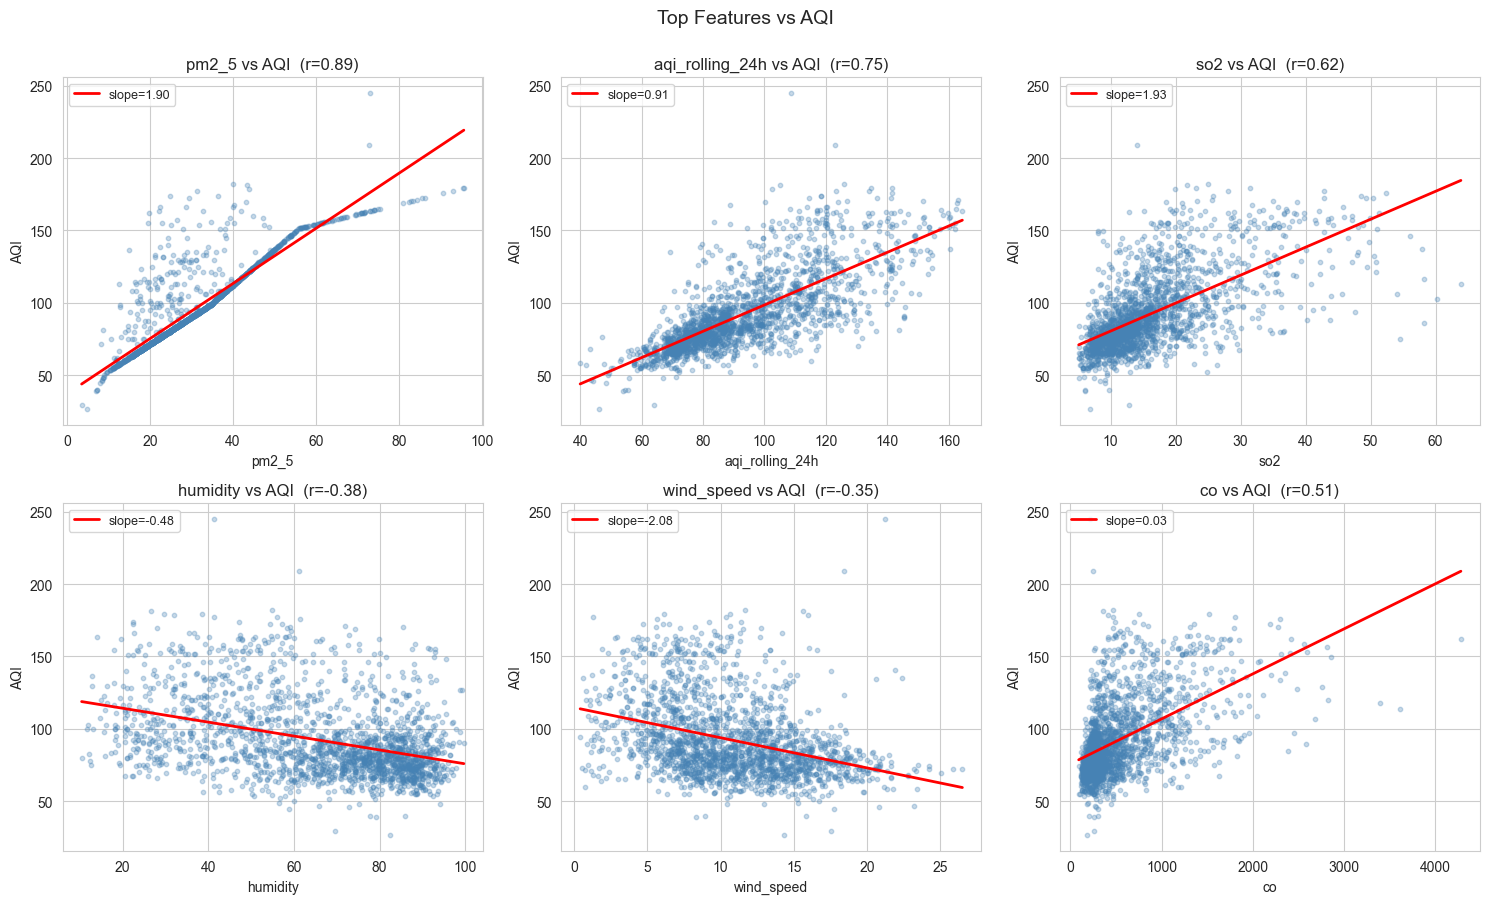

In [18]:
# Section 8: Top Features vs AQI (Scatter Plots)
top_features = ['pm2_5', 'aqi_rolling_24h', 'so2', 'humidity', 'wind_speed', 'co']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flatten(), top_features):
    # Sample to keep plot readable
    sample = df[[col, 'aqi']].dropna().sample(min(2000, len(df)), random_state=42)
    ax.scatter(sample[col], sample['aqi'], alpha=0.3, s=10, color='steelblue')
    
    # Trend line
    z = np.polyfit(sample[col], sample['aqi'], 1)
    x_range = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(x_range, np.poly1d(z)(x_range), color='red', linewidth=2, label=f'slope={z[0]:.2f}')
    
    r = sample[col].corr(sample['aqi'])
    ax.set_title(f'{col} vs AQI  (r={r:.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('AQI')
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('Top Features vs AQI', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

**Top feature scatter plot insights:**

- **PM2.5 vs AQI** shows an almost linear relationship (slope ≈ 1.9) — confirming that US AQI is essentially a PM2.5-driven index
- **aqi_rolling_24h vs AQI** is the tightest among engineered features — recent average AQI is a strong baseline predictor
- **Humidity and wind speed** both show clear negative trends but with wide scatter — useful directional signals but not deterministic on their own
- **CO vs AQI** has a long tail of high-CO outliers mapped to moderate AQI values, suggesting CO spikes don't always translate to AQI spikes (PM2.5 must also be elevated)
- The scatter shapes confirm that no single feature is fully sufficient — the model needs combinations of pollutants + recent history + weather to forecast accurately

## Summary of Key EDA Findings

**Data:**
- 9,048 hourly readings spanning April 2025 – May 2026 (~12.5 months)
- Single 4-day gap at backfill/cron handover; otherwise continuous
- No duplicates; null patterns confined to expected boundary effects

**Target (AQI):**
- Right-skewed, mean 93.2, median 85.8, range 23.9–389.7
- 70.7% of hours are "Moderate" (51–100), the dominant baseline
- Hazardous events are extremely rare (~0.01%), justifying alert-based UX

**Time patterns:**
- Clear diurnal cycle peaking ~2 PM PKT
- No weekly cycle — Karachi pollution is baseline industrial, not commuter-driven
- Strong seasonal cycle: winter peak (Nov ~118), summer trough (Sep ~78)

**Feature importance (via correlation):**
- PM2.5 dominates (r=0.88) — US AQI is largely PM2.5-driven
- Recent AQI history (rolling/lag) provides strong autocorrelation signal
- Humidity (-0.40) and wind speed (-0.32) are the most useful weather features
- Hour, day-of-week, and weekend flags add little signal directly

**Pollutant chemistry:**
- NO2 ↔ CO highly correlated (0.72) — shared combustion sources
- NO2 ↔ O3 anticorrelated (-0.56) — classic photochemistry
- PM10 independent of combustion pollutants — likely dust-driven

**Forecasting implications:**
- Temporal autocorrelation decays smoothly with horizon (0.63 → 0.49 → 0.41 at 24/48/72h)
- This explains the natural degradation of model R² at longer horizons
- Justifies widening confidence intervals as horizon increases